In [1]:
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.cumsum(axis=0).round().astype(np.int32)
    y = dy.cumsum(axis=0).round().astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(-margin, frame_shape[1] + margin, (ants_num,))
        start_y = np.random.randint(-margin, frame_shape[0] + margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories


def draw_traj(trajectories, frame_shape: tuple, ants_num: int):
    
    colors = sns.color_palette(palette='bright', n_colors=ants_num)
    colors = [tuple([int(c*255) for c in color]) for color in colors]

    bg = np.zeros(shape=(*frame_shape, 3), dtype=np.uint8)
    trajs = []
    for ant in range(trajectories.shape[1]):
        trajs.append(np.array([np.array(traj) for traj in trajectories[:, ant]]))
    for ant, color in  zip(trajs, colors):

        cv2.polylines(bg, [ant], isClosed=False, color=color, thickness=2)

    plt.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB))
    plt.show()

def draw_ants_with_direction(trajectories, output_path:str, frame_num: int, ants_num: int, frame_shape: tuple, ant_length = 5, ant_width=2, smooth_window:int=3, imshow:bool=False):
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    frame_size = (frame_shape[1], frame_shape[0])
    if output_path:
        out = cv2.VideoWriter(output_path, fourcc, 24.0, frame_size, isColor=True)
    for frame_idx in range(frame_num):
        # frame = gen_poisson_bg(frame_shape, sense=0.43)
        frame = np.ones((*frame_shape, 3), dtype=np.uint8)*255
        
        for ant_idx in range(ants_num):
            
            x, y = trajectories[frame_idx, ant_idx]
            start_index = max(0, frame_idx-smooth_window)
            dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
            dy = y - trajectories[start_index:frame_idx, ant_idx, 1].mean()
            angle = np.arctan2(dy, dx) * 180 / np.pi
            
            center = (int(x), int(y))
            axes = (ant_length, ant_width)
            cv2.ellipse(frame, center, axes, angle, 0, 360, 
                       (100, 100, 100), -1)
        frame = cv2.GaussianBlur(frame, ksize=(7,7), sigmaX=1.0)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if output_path:
            out.write(frame)

        if imshow:
            # cv2.imshow('frame', frame)
            plt.figure(figsize=(12, 8))
            plt.imshow(frame)
            plt.axis('off')
            plt.show()
            
            clear_output(wait=True)
            if cv2.waitKey(1) & 0xFF == 27:
                cv2.destroyAllWindows()
                if output_path:
                    out.release()
                break

    if output_path:
        out.release()
    cv2.destroyAllWindows()

In [2]:
from collections import defaultdict
from typing import Optional, Union, Tuple

import numpy as np


def _as_radii(radii: Union[float, np.ndarray], n: int) -> np.ndarray:
    """
    Приводит радиусы к массиву длины n.
    """
    if np.isscalar(radii):
        return np.full(n, float(radii), dtype=np.float32)

    radii = np.asarray(radii, dtype=np.float32)

    if radii.size == 1:
        return np.full(n, float(radii.ravel()[0]), dtype=np.float32)

    if radii.shape != (n,):
        raise ValueError("radii должен быть скаляром или массивом длины ants_num")

    return radii


def _clip_to_bounds(
    positions: np.ndarray,
    bounds: Optional[Tuple[float, float, float, float]],
) -> np.ndarray:
    """
    Обрезает позиции по заданным границам.

    bounds = (xmin, xmax, ymin, ymax)
    """
    if bounds is None:
        return positions

    xmin, xmax, ymin, ymax = bounds

    positions[:, 0] = np.clip(positions[:, 0], xmin, xmax)
    positions[:, 1] = np.clip(positions[:, 1], ymin, ymax)

    return positions


def _neighbor_pairs(positions: np.ndarray, cell_size: float):
    """
    Возвращает потенциально близкие пары особей с использованием
    пространственной сетки.

    Это нужно, чтобы не перебирать все пары O(N^2).
    """
    grid = defaultdict(list)

    for i, p in enumerate(positions):
        key = (
            int(np.floor(p[0] / cell_size)),
            int(np.floor(p[1] / cell_size)),
        )
        grid[key].append(i)

    # Смещения соседних ячеек, чтобы каждую пару проверить один раз.
    neighbor_offsets = (
        (1, 0),
        (0, 1),
        (1, 1),
        (1, -1),
    )

    for (cx, cy), indices in grid.items():
        m = len(indices)

        # Пары внутри одной ячейки.
        for a in range(m):
            i = indices[a]
            for b in range(a + 1, m):
                j = indices[b]
                yield i, j

        # Пары с соседними ячейками.
        for dx, dy in neighbor_offsets:
            other = grid.get((cx + dx, cy + dy))
            if other is None:
                continue

            for i in indices:
                for j in other:
                    yield i, j


def _separate_positions(
    positions: np.ndarray,
    radii: np.ndarray,
    max_iter: int = 8,
    bounds: Optional[Tuple[float, float, float, float]] = None,
    rng: Optional[np.random.Generator] = None,
    relaxation: float = 1.0,
) -> np.ndarray:
    """
    Итеративно разводит позиции особей так, чтобы расстояние между центрами
    было не меньше r_i + r_j.
    """
    positions = np.asarray(positions, dtype=np.float32)
    pos = positions.copy()

    pos = _clip_to_bounds(pos, bounds)

    n = pos.shape[0]

    if n < 2:
        return pos

    if max_iter <= 0:
        return pos

    max_radius = float(np.max(radii))

    if max_radius <= 0.0:
        return pos

    if rng is None:
        rng = np.random.default_rng()

    # Размер ячейки выбираем по максимальному диаметру.
    cell_size = max(1.0, 2.0 * max_radius)

    for _ in range(max_iter):
        moved = False

        for i, j in _neighbor_pairs(pos, cell_size):
            min_dist = float(radii[i] + radii[j])

            if min_dist <= 0.0:
                continue

            delta = pos[j] - pos[i]
            dist2 = float(delta[0] * delta[0] + delta[1] * delta[1])
            min_dist2 = min_dist * min_dist

            if dist2 < min_dist2:
                moved = True

                dist = float(np.sqrt(dist2))

                if dist < 1e-6:
                    # Если точки совпадают, задаем случайное направление.
                    angle = float(rng.random()) * 2.0 * np.pi
                    direction = np.array(
                        [np.cos(angle), np.sin(angle)],
                        dtype=np.float32,
                    )
                else:
                    direction = delta / dist

                overlap = min_dist - dist

                # Каждая особь смещается на половину перекрытия.
                correction = 0.5 * relaxation * overlap * direction

                pos[i] -= correction
                pos[j] += correction

        pos = _clip_to_bounds(pos, bounds)

        if not moved:
            break

    return pos


def make_frame_bounds(
    frame_shape: tuple,
    margin: float = 0.0,
    inside: bool = False,
) -> Tuple[float, float, float, float]:
    """
    Возвращает границы области в формате:

        (xmin, xmax, ymin, ymax)

    Параметры:
    -----------
    frame_shape : tuple
        (height, width)

    margin : float
        Отступ от границ кадра.

    inside : bool
        Если True, ограничивает траектории внутри кадра с отступом margin:
            [margin, width - margin - 1]

        Если False, разрешает находиться в расширенной области:
            [-margin, width + margin - 1]

        Это полезно, если объекты могут заходить в кадр и выходить из него.
    """
    height, width = frame_shape

    if inside:
        xmin = margin
        xmax = width - margin - 1
        ymin = margin
        ymax = height - margin - 1
    else:
        xmin = -margin
        xmax = width + margin - 1
        ymin = -margin
        ymax = height + margin - 1

    if xmin > xmax or ymin > ymax:
        raise ValueError("Некорректные границы после вычисления")

    return float(xmin), float(xmax), float(ymin), float(ymax)


def postprocess_collisions(
    trajectories: np.ndarray,
    radii: Union[float, np.ndarray] = 1.0,
    bounds: Optional[Tuple[float, float, float, float]] = None,
    max_iter: int = 8,
    substeps: int = 1,
    relaxation: float = 1.0,
    seed: Optional[int] = None,
    return_float: bool = False,
) -> np.ndarray:
    """
    Постобработка траекторий для устранения столкновений особей.

    Параметры:
    -----------
    trajectories : np.ndarray
        Массив формы (frame_num, ants_num, 2).

    radii : float или np.ndarray
        Радиус тела особи. Если нужно, чтобы центры двух особей
        не подходили ближе чем D пикселей, задайте радиус = D / 2.

        Для разных радиусов у разных особей передайте массив длины ants_num.

    bounds : tuple или None
        Границы области: (xmin, xmax, ymin, ymax).
        Если None, границы не учитываются.

    max_iter : int
        Число итераций разрешения пересечений на каждом шаге.

    substeps : int
        Число подшагов между соседними кадрами.

        Это полезно, если скорости большие и особи могут "проскакивать"
        друг сквозь друга между кадрами.

        Например, substeps=2 или substeps=4 уменьшают туннелирование.

    relaxation : float
        Коэффициент релаксации. Обычно 1.0.
        Можно поставить 0.7-0.9 для более мягкой коррекции.

    seed : int или None
        Seed для воспроизводимости.

    return_float : bool
        Если True, возвращает float-траектории.
        Если False, возвращает int после округления.
    """
    raw = np.asarray(trajectories, dtype=np.float32).copy()

    if raw.ndim != 3 or raw.shape[2] != 2:
        raise ValueError("trajectories должен иметь форму (frame_num, ants_num, 2)")

    frame_num, ants_num, _ = raw.shape

    if frame_num == 0 or ants_num == 0:
        if return_float:
            return raw
        return np.round(raw).astype(np.int32)

    radii = _as_radii(radii, ants_num)
    rng = np.random.default_rng(seed)

    substeps = max(1, int(substeps))

    out = np.empty_like(raw)

    # Начальный кадр.
    out[0] = _separate_positions(
        raw[0],
        radii=radii,
        max_iter=max_iter,
        bounds=bounds,
        rng=rng,
        relaxation=relaxation,
    )

    # Последующие кадры.
    for t in range(1, frame_num):
        # Исходное приращение из сгенерированной траектории.
        desired_delta = raw[t] - raw[t - 1]

        # Двигаем уже скорректированную предыдущую позицию.
        current_pos = out[t - 1].copy()

        step_delta = desired_delta / float(substeps)

        for _ in range(substeps):
            proposed_pos = current_pos + step_delta

            proposed_pos = _separate_positions(
                proposed_pos,
                radii=radii,
                max_iter=max_iter,
                bounds=bounds,
                rng=rng,
                relaxation=relaxation,
            )

            current_pos = proposed_pos

        out[t] = current_pos

    if return_float:
        return out

    return np.round(out).astype(np.int32)

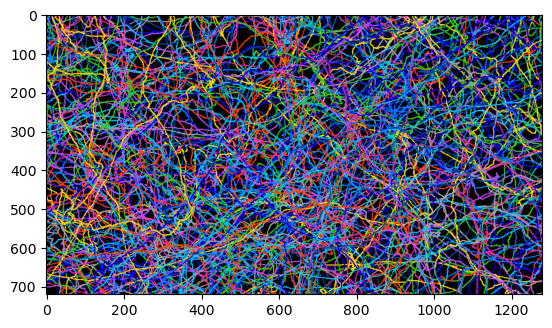

In [14]:
np.random.seed(42)
config = {
'frame_num' : 10000,
# 'frame_shape' : (720, 1280),
'frame_shape' : (720, 1280),
'margin': 100,
'hurst_move': 1.2,
'hurst_species': 0.5,
'ants_num' : 200,
'start_point' : None
}
trajectories = gen_traj(**config)
traj_fixed = postprocess_collisions(
    trajectories,
    radii=4.0,
    max_iter=8,
    substeps=1,
    seed=42,
)
out_of_bounds = ((traj_fixed <= config['frame_shape'][::-1]).all(axis=-1)) & ((traj_fixed >= 0).all(axis=-1))
out_of_bounds = np.expand_dims(out_of_bounds, axis=2).repeat(2, axis=2)

trajectories_cut = np.where(out_of_bounds, traj_fixed, np.nan)
draw_traj(traj_fixed, config['frame_shape'], config['ants_num'])

In [15]:
draw_ants_with_direction(traj_fixed,
                        output_path='../data/collision_model_ants.mp4',
                        frame_num=config['frame_num'],
                        ants_num=config['ants_num'],
                        frame_shape=config['frame_shape'],
                        ant_length=3,
                        ant_width=1,
                        smooth_window=7,
                        imshow=False)


/tmp/ipykernel_3447946/2470994793.py:64: RuntimeWarning: Mean of empty slice.
  dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
/home/akhiyarov/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3447946/2470994793.py:65: RuntimeWarning: Mean of empty slice.
  dy = y - trajectories[start_index:frame_idx, ant_idx, 1].mean()


In [16]:
flat_trajectories = trajectories_cut.reshape(-1, 2)

frame_indices = np.repeat(np.arange(trajectories_cut.shape[0]), trajectories_cut.shape[1])
ant_indices = np.tile(np.arange(trajectories_cut.shape[1]), trajectories_cut.shape[0])

df = pd.DataFrame({
    'frame': frame_indices,
    'ant_id': ant_indices,
    'x': flat_trajectories[:, 0],
    'y': flat_trajectories[:, 1]
})

df = df.sort_values(['ant_id','frame'])
df.to_csv('../data/collision_model_ants_gt.csv', index=False)